# nb11 -- MLP variant comparison
Trains all 12 (architecture, penalty) variants from `src/models/architectures.py`
on the same corrected RNA -> protein data, and compares them on accuracy
(train/test Pearson r) and interpretability (cognate rank-1 count, effective
genes per protein).

Consolidates what nb05-nb09 did across five separate notebooks into one run.
nb05-nb09 are left as-is for history; this notebook is the current pipeline
going forward, and the one to re-point at NeurIPS (GSE194122) later.

All model/training/evaluation logic lives in `src/models/architectures.py`,
`src/training/train.py`, `src/analysis/evaluate.py` -- this notebook is
execution only, no function definitions beyond the data-normalization block
(not yet extracted to `src/`, see note below).

## Environment setup (Colab or local)

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config
`src/models`, `src/training`, `src/analysis` are real packages under `BASE_PATH`
(no `__init__.py` needed -- Python 3 namespace packages), so they import
directly once `BASE_PATH` is on `sys.path`.

In [5]:
!pip install -q -U "typing_extensions>=4.13"

In [3]:
import sys
sys.path.insert(0, str(BASE_PATH))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from src.models.architectures import VARIANTS, build_variant
from src.training.train import fit_model, make_loader
from src.analysis.normalize import normalize_rna, clr_normalize, regress_out_library_size
from src.analysis.evaluate import (
    evaluate_per_protein,
    compute_importance,
    cognate_gene_rank,
    effective_genes_per_protein,
    train_test_metrics,
)

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'mlp_variant_comparison'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM   = 64      # defined here, not hardcoded in src/models/architectures.py
BATCH_SIZE   = 256
NUM_EPOCHS   = 100
PATIENCE     = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

# Train all 12 registered variants by default -- narrow this list to re-run a subset.
VARIANTS_TO_RUN = list(VARIANTS.keys())
print('Variants to run:', VARIANTS_TO_RUN)

Variants to run: ['mlp_no_l1', 'mlp_fc1', 'mlp_fc2', 'mlp_fc1_fc2', 'mlp_fc1_group_fc2', 'lasso', 'skip_no_l1', 'skip_fc1', 'skip_fc2', 'skip_fc1_fc2', 'skip_fc1_fc2_direct', 'skip_direct']


## Load checkpoint and gene mapping
Same as nb05-nb09 -- splits GEX/ADT, rebuilds the 163-gene matched set from the saved mapping.

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Gene union (matched + HVG)
Same construction as nb03/nb05-nb09 -- matched coupling genes are always kept
even if not top-variance. Not yet extracted to `src/` -- candidate for a future
`src/preprocessing.py` alongside the normalization block below.

In [5]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize and correct (same pipeline as nb06-nb09)
Log1p(CP10k) RNA, CLR protein, library-size regression on both -- unchanged so
results are comparable to the historical notebooks.

In [10]:
# rna_adata = normalize_rna(covid_gex, gene_union)
# X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
# X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

# rna_raw_for_size = rna_adata.layers['raw']
# rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

# X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

# print(f'X_rna_corr: {X_rna_corr.shape} | Y_protein_corr: {Y_protein_corr.shape}')

## Train / val / test split

In [5]:
from sklearn.model_selection import train_test_split

n_cells = covid_gex.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [9]:
train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## Train all variants
One `build_variant` + `fit_model` call per entry in `VARIANTS_TO_RUN`. Each
variant's best-validation checkpoint is saved to `MODELS_DIR`.

In [ ]:
trained_models = {}
trained_histories = {}

for name in VARIANTS_TO_RUN:
    print(f'\n=== Training {name} ===')
    model, penalty_fn = build_variant(
        name,
        rna_dim=X_rna_corr.shape[1],
        protein_dim=Y_protein_corr.shape[1],
        hidden_dim=HIDDEN_DIM,
    )
    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        penalty_fn=penalty_fn,
        lr=1e-4,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        train_device=DEVICE,
        checkpoint_path=MODELS_DIR / f'{name}.pt',
    )
    trained_models[name] = model
    trained_histories[name] = history


=== Training lasso ===
  Epoch 0: train_loss=0.5964, val_loss=0.3222
  Epoch 10: train_loss=0.2903, val_loss=0.2774
  Epoch 20: train_loss=0.2889, val_loss=0.2765
  Epoch 30: train_loss=0.2887, val_loss=0.2763
  Early stopping at epoch 37

=== Training mlp_fc2 ===
  Epoch 0: train_loss=0.4428, val_loss=0.3395
  Epoch 10: train_loss=0.2828, val_loss=0.2663
  Epoch 20: train_loss=0.2679, val_loss=0.2616
  Epoch 30: train_loss=0.2626, val_loss=0.2598
  Epoch 40: train_loss=0.2595, val_loss=0.2588
  Epoch 50: train_loss=0.2573, val_loss=0.2581
  Epoch 60: train_loss=0.2558, val_loss=0.2577
  Epoch 70: train_loss=0.2545, val_loss=0.2574
  Epoch 80: train_loss=0.2535, val_loss=0.2572
  Epoch 90: train_loss=0.2526, val_loss=0.2570

=== Training skip_fc1_fc2 ===
  Epoch 0: train_loss=0.5359, val_loss=0.3385
  Epoch 10: train_loss=0.2603, val_loss=0.2675
  Epoch 20: train_loss=0.2551, val_loss=0.2673
  Early stopping at epoch 30


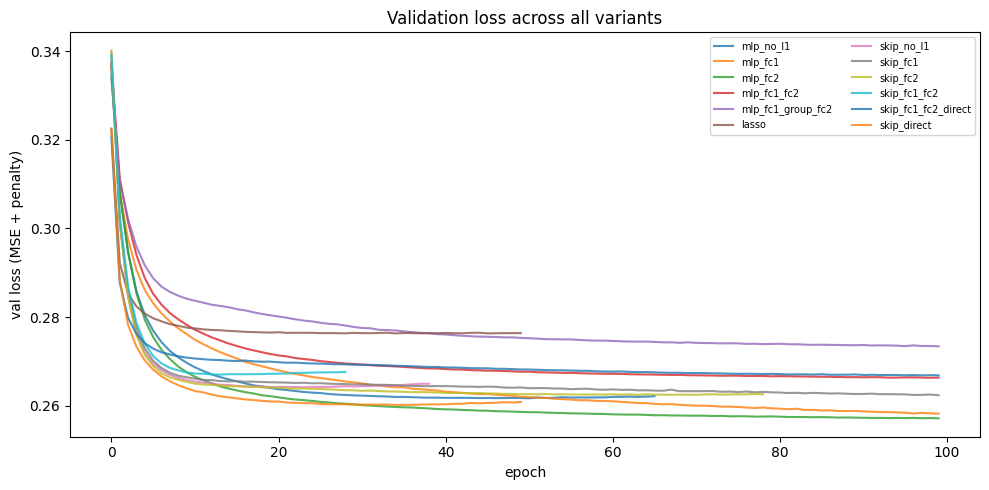

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, history in trained_histories.items():
    ax.plot(history['val_loss'], label=name, alpha=0.8)
ax.set_xlabel('epoch')
ax.set_ylabel('val loss (MSE + penalty)')
ax.set_title('Validation loss across all variants')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nb11_val_loss_all_variants.png', dpi=150)
plt.show()

## Comparison table -- accuracy vs. interpretability
Train/test Pearson r, cognate rank-1 count, and median effective genes per
protein, side by side for every trained variant.

In [13]:
comparison_rows = []
per_variant_metrics = {}
per_variant_ranks = {}

for name, model in trained_models.items():
    metrics = train_test_metrics(
        model, X_rna_corr[train_idx], Y_protein_corr[train_idx],
        X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names,
    )
    per_variant_metrics[name] = metrics

    importance_df = compute_importance(model, gene_union, matched_adt_names)
    cognate_ranks = cognate_gene_rank(importance_df, gene_map)
    per_variant_ranks[name] = cognate_ranks

    eff_genes = effective_genes_per_protein(model, matched_adt_names, gene_union)

    comparison_rows.append({
        'variant': name,
        'median_train_r': metrics['pearson_r_train'].median(),
        'median_test_r': metrics['pearson_r_test'].median(),
        'r_gap': metrics['r_gap'].median(),
        'cognate_rank1_count': int((cognate_ranks['cognate_rank'] == 1).sum()),
        'cognate_rank1_total': len(cognate_ranks),
        'median_effective_genes': eff_genes.median(),
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values('median_test_r', ascending=False).reset_index(drop=True)
comparison_table

,variant,median_train_r,median_test_r,r_gap,cognate_rank1_count,cognate_rank1_total,median_effective_genes
0,mlp_fc2,0.454127,0.429071,0.022949,14,163,2091.0
1,mlp_fc1,0.435717,0.428009,0.010573,7,163,1083.0
2,skip_direct,0.470743,0.419445,0.043636,14,163,8.0
3,skip_fc1,0.479229,0.413186,0.068188,11,163,1847.0
4,skip_no_l1,0.487097,0.413013,0.078775,18,163,1863.0
5,mlp_no_l1,0.469363,0.411930,0.045780,7,163,2092.0
6,skip_fc2,0.476405,0.408773,0.071827,15,163,1858.0
7,skip_fc1_fc2,0.451666,0.402760,0.054637,31,163,1831.0
8,mlp_fc1_fc2,0.396276,0.399144,0.003540,8,163,683.0
9,skip_fc1_fc2_direct,0.399079,0.393510,0.005499,26,163,48.0


## Raw correlation sanity check
Model-independent, no retraining needed: for each protein, the raw Pearson r
with its cognate gene and with the model's chosen top-predictor gene,
computed directly from the data. Catches two failure modes that
importance-weight-based ranking alone can miss:
- **`n_weak_raw_corr_top_pick`** -- the model's #1 gene barely correlates with
  the protein at all (possible weight artifact, not a real relationship).
- **`n_strong_cognate_not_top`** -- the cognate gene has a strong raw
  correlation but the model still didn't rank it #1 (the model missed an easy case).

Cheap enough to run for every variant -- adds four summary columns to `comparison_table`.

In [14]:
from src.analysis.evaluate import raw_correlation_check, raw_correlation_summary

raw_corr_summary_rows = []
per_variant_raw_corr = {}

for name in trained_models:
    check_df = raw_correlation_check(
        per_variant_ranks[name], X_rna_corr[test_idx], Y_protein_corr[test_idx],
        gene_union, matched_adt_names,
    )
    per_variant_raw_corr[name] = check_df
    raw_corr_summary_rows.append({'variant': name, **raw_correlation_summary(check_df)})

raw_corr_summary_df = pd.DataFrame(raw_corr_summary_rows)
comparison_table = comparison_table.merge(raw_corr_summary_df, on='variant')
comparison_table

,variant,median_train_r,median_test_r,r_gap,cognate_rank1_count,cognate_rank1_total,median_effective_genes,raw_corr_rank_spearman_rho,raw_corr_rank_spearman_p,n_weak_raw_corr_top_pick,n_strong_cognate_not_top
0,mlp_fc2,0.454127,0.429071,0.022949,14,163,2091.0,-0.707517,4.698231e-26,90,26
1,mlp_fc1,0.435717,0.428009,0.010573,7,163,1083.0,-0.723506,1.054291e-27,87,30
2,skip_direct,0.470743,0.419445,0.043636,14,163,8.0,-0.591003,9.986979e-17,100,27
3,skip_fc1,0.479229,0.413186,0.068188,11,163,1847.0,-0.463681,4.564317e-10,112,33
4,skip_no_l1,0.487097,0.413013,0.078775,18,163,1863.0,-0.458151,7.773681e-10,114,28
5,mlp_no_l1,0.469363,0.411930,0.045780,7,163,2092.0,-0.566343,3.295876e-15,117,32
6,skip_fc2,0.476405,0.408773,0.071827,15,163,1858.0,-0.431031,9.262695e-09,125,31
7,skip_fc1_fc2,0.451666,0.402760,0.054637,31,163,1831.0,-0.571180,1.698578e-15,100,23
8,mlp_fc1_fc2,0.396276,0.399144,0.003540,8,163,683.0,-0.720490,2.201982e-27,76,29
9,skip_fc1_fc2_direct,0.399079,0.393510,0.005499,26,163,48.0,-0.725625,6.247556e-28,65,24


## Per-protein evaluation deep-dive (reference variant)
Full detail for a single variant -- defaults to the top row of `comparison_table`
(best `median_test_r`). Override `REFERENCE_VARIANT` manually to inspect a
different one (e.g. the best-interpretability variant instead).

In [15]:
REFERENCE_VARIANT = comparison_table.iloc[0]['variant']
print(f'Reference variant: {REFERENCE_VARIANT}')

reference_model = trained_models[REFERENCE_VARIANT]

per_protein_test = evaluate_per_protein(
    reference_model, X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names,
)
per_protein_test.sort_values('pearson_r').reset_index(drop=True)

Reference variant: mlp_fc2


,protein,pearson_r,r2
0,AB_MCAM,0.141868,0.019491
1,AB_CTLA4,0.153468,0.022053
2,AB_KIT,0.156063,0.024267
3,AB_ITGAE,0.162570,0.025913
4,AB_CD1a,0.167563,0.027548
...,...,...,...
158,AB_CD8,0.846637,0.716582
159,AB_CD3,0.860129,0.739763
160,AB_CD19,0.861252,0.741454
161,AB_CD5,0.874319,0.764378


In [16]:
reference_check_df = per_variant_raw_corr[REFERENCE_VARIANT]

rho, p = raw_correlation_summary(reference_check_df)['raw_corr_rank_spearman_rho'], \
         raw_correlation_summary(reference_check_df)['raw_corr_rank_spearman_p']
print(f'Spearman corr (|cognate raw r| vs cognate_rank): {rho:.3f} (p={p:.2e})')
print('(expected negative -- higher raw correlation should mean a lower/better rank)')

print(f"\nProteins where the model's #1 gene has |raw r| < 0.1: "
      f"{reference_check_df['top_predictor_weak_raw_corr'].sum()} / {len(reference_check_df)}")
print(f"Proteins with strong raw cognate correlation (|r|>0.3) but NOT ranked #1: "
      f"{reference_check_df['cognate_strong_but_not_top'].sum()}")

reference_check_df[reference_check_df['cognate_strong_but_not_top']].sort_values('cognate_raw_r', key=abs, ascending=False)

Spearman corr (|cognate raw r| vs cognate_rank): -0.708 (p=4.70e-26)
(expected negative -- higher raw correlation should mean a lower/better rank)

Proteins where the model's #1 gene has |raw r| < 0.1: 90 / 163
Proteins with strong raw cognate correlation (|r|>0.3) but NOT ranked #1: 26


,protein,cognate_gene,cognate_rank,cognate_raw_r,top_predictor_gene,top_predictor_raw_r,top_predictor_weak_raw_corr,cognate_strong_but_not_top
17,AB_CD8,CD8A,2,0.730205,CD8B,0.768703,False,True
30,AB_CD3,CD3D,7,0.654425,MT-CO1,0.062882,True,True
21,AB_IL7R,IL7R,3,0.626874,EEF1A1,0.416123,False,True
59,AB_CD19,CD19,39,0.568680,EEF1A1,-0.022135,True,True
22,AB_KLRD1,KLRD1,3,0.542811,KLRC1,0.572344,False,True
20,AB_CD7,CD7,3,0.541968,EEF1A1,0.298856,False,True
37,AB_CD2,CD2,13,0.462767,MT-CO1,0.116754,False,True
24,AB_CD5,CD5,4,0.441116,MT-CO1,0.054387,True,True
56,AB_CD22,CD22,37,0.438765,EEF1A1,0.008683,True,True
94,AB_CLEC12A,CLEC12A,335,0.420019,TNFRSF17,-0.080016,True,True


## Bootstrap + permutation-null validation
Retrains `VALIDATE_VARIANTS` on bootstrap resamples and shuffled-protein nulls
to check whether the point-estimate rank1/importance numbers above are stable,
or just this particular split. This is the expensive step --
`n_bootstraps + n_null_perms` extra training passes per variant validated, so
only the two most decision-relevant variants are validated by default: the
best-accuracy variant and the best-interpretability variant (by cognate
rank-1 count). Override `VALIDATE_VARIANTS` manually for a different pair.

In [12]:
comparison_table = pd.read_csv(RESULTS_DIR / 'nb11_variant_comparison.csv')

In [16]:
comparison_table

,variant,median_train_r,median_test_r,r_gap,cognate_rank1_count,cognate_rank1_total,median_effective_genes,raw_corr_rank_spearman_rho,raw_corr_rank_spearman_p,n_weak_raw_corr_top_pick,n_strong_cognate_not_top
0,mlp_fc2,0.454127,0.429071,0.022949,14,163,2091.0,-0.707517,4.698231e-26,90,26
1,mlp_fc1,0.435717,0.428009,0.010573,7,163,1083.0,-0.723506,1.054291e-27,87,30
2,skip_direct,0.470743,0.419445,0.043636,14,163,8.0,-0.591003,9.986979e-17,100,27
3,skip_fc1,0.479229,0.413186,0.068188,11,163,1847.0,-0.463681,4.564317e-10,112,33
4,skip_no_l1,0.487097,0.413013,0.078775,18,163,1863.0,-0.458151,7.773681e-10,114,28
5,mlp_no_l1,0.469363,0.411930,0.045780,7,163,2092.0,-0.566343,3.295876e-15,117,32
6,skip_fc2,0.476405,0.408773,0.071827,15,163,1858.0,-0.431031,9.262695e-09,125,31
7,skip_fc1_fc2,0.451666,0.402760,0.054637,31,163,1831.0,-0.571180,1.698578e-15,100,23
8,mlp_fc1_fc2,0.396276,0.399144,0.003540,8,163,683.0,-0.720490,2.201982e-27,76,29
9,skip_fc1_fc2_direct,0.399079,0.393510,0.005499,26,163,48.0,-0.725625,6.247556e-28,65,24


In [17]:
from src.training.validation import ValidationConfig, validate_variant

N_BOOTSTRAPS = 5
N_NULL_PERMS = 5
TOP_K_GENES = 20
MIN_BOOTSTRAP_FREQUENCY = 0.8
NULL_PERCENTILE = 95.0
AUX_NUM_EPOCHS = 40   # cheaper than the main NUM_EPOCHS -- these are diagnostic retrains, not the final fit
AUX_PATIENCE = 8

best_accuracy_variant = comparison_table.sort_values('median_test_r', ascending=False).iloc[0]['variant']
best_interpretability_variant = comparison_table.sort_values('cognate_rank1_count', ascending=False).iloc[0]['variant']
VALIDATE_VARIANTS = sorted(set([best_accuracy_variant, best_interpretability_variant]))
VALIDATE_VARIANTS = ['lasso', 'mlp_fc2', 'skip_fc1_fc2']
print(f'Validating: {VALIDATE_VARIANTS}')

validation_config = ValidationConfig(
    rna_dim=X_rna_corr.shape[1],
    protein_dim=Y_protein_corr.shape[1],
    hidden_dim=HIDDEN_DIM,
    batch_size=BATCH_SIZE,
    train_device=DEVICE,
    aux_num_epochs=AUX_NUM_EPOCHS,
    aux_patience=AUX_PATIENCE,
)

Validating: ['lasso', 'mlp_fc2', 'skip_fc1_fc2']


In [23]:
validation_results = {}

for variant_name in VALIDATE_VARIANTS:
    print(f'\n=== Validating {variant_name} ===')
    results = validate_variant(
        trained_models[variant_name], variant_name, train_idx, val_idx,
        X_rna_corr, Y_protein_corr, gene_union, matched_adt_names,
        validation_config,
        n_bootstraps=N_BOOTSTRAPS, n_null_perms=N_NULL_PERMS, top_k=TOP_K_GENES,
        min_bootstrap_frequency=MIN_BOOTSTRAP_FREQUENCY, null_percentile=NULL_PERCENTILE,
    )
    validation_results[variant_name] = results

    thresholds = results['null_thresholds']['null_threshold']
    validated = results['validated']
    rank1_df = results['bootstrap_rank1']
    print(f'\n{variant_name}:')
    print(f'  Median null threshold: {thresholds.median():.6f}')
    print(f"  Validated pairs (aggregate top-{TOP_K_GENES} criterion): {validated['validated'].sum()} / {len(validated)}")
    print(f"  Proteins with a stable (>={MIN_BOOTSTRAP_FREQUENCY:.0%}) rank-1 gene: "
          f"{(rank1_df['rank1_match_frequency'] >= MIN_BOOTSTRAP_FREQUENCY).sum()} / {len(rank1_df)}")


=== Validating lasso ===
  Bootstrap 1/5 (lasso)...
  Bootstrap 2/5 (lasso)...
  Bootstrap 3/5 (lasso)...
  Bootstrap 4/5 (lasso)...
  Bootstrap 5/5 (lasso)...
  Null permutation 1/5 (lasso)...
  Null permutation 2/5 (lasso)...
  Null permutation 3/5 (lasso)...
  Null permutation 4/5 (lasso)...
  Null permutation 5/5 (lasso)...

lasso:
  Median null threshold: 0.000320
  Validated pairs (aggregate top-20 criterion): 2268 / 3260
  Proteins with a stable (>=80%) rank-1 gene: 133 / 163

=== Validating mlp_fc2 ===
  Bootstrap 1/5 (mlp_fc2)...
  Bootstrap 2/5 (mlp_fc2)...
  Bootstrap 3/5 (mlp_fc2)...
  Bootstrap 4/5 (mlp_fc2)...
  Bootstrap 5/5 (mlp_fc2)...
  Null permutation 1/5 (mlp_fc2)...
  Null permutation 2/5 (mlp_fc2)...
  Null permutation 3/5 (mlp_fc2)...
  Null permutation 4/5 (mlp_fc2)...
  Null permutation 5/5 (mlp_fc2)...

mlp_fc2:
  Median null threshold: 0.000217
  Validated pairs (aggregate top-20 criterion): 1350 / 3260
  Proteins with a stable (>=80%) rank-1 gene: 117 / 16

## Save results

In [24]:
# comparison_table.to_csv(RESULTS_DIR / 'nb11_variant_comparison.csv', index=False)

# for name in trained_models:
#     per_variant_metrics[name].to_csv(RESULTS_DIR / f'nb11_{name}_per_protein_metrics.csv', index=False)
#     per_variant_ranks[name].to_csv(RESULTS_DIR / f'nb11_{name}_cognate_ranks.csv', index=False)

# print(f'Saved to {RESULTS_DIR}')
# print('  nb11_variant_comparison.csv            -- all variants, accuracy + interpretability side by side')
# print('  nb11_<variant>_per_protein_metrics.csv -- per variant, train/test Pearson r + R2')
# print('  nb11_<variant>_cognate_ranks.csv       -- per variant, cognate RNA rank per protein')
# print(f'  checkpoints/<variant>.pt               -- best-validation model weights, {len(trained_models)} variants')

# for name in trained_models:
#     per_variant_raw_corr[name].to_csv(RESULTS_DIR / f'nb11_{name}_raw_correlation_check.csv', index=False)

for variant_name, results in validation_results.items():
    results['bootstrap_topk'].to_csv(RESULTS_DIR / f'nb11_{variant_name}_bootstrap_topk.csv', index=False)
    results['bootstrap_rank1'].to_csv(RESULTS_DIR / f'nb11_{variant_name}_bootstrap_rank1.csv', index=False)
    results['null_thresholds'].to_csv(RESULTS_DIR / f'nb11_{variant_name}_null_thresholds.csv', index=False)
    results['validated'].to_csv(RESULTS_DIR / f'nb11_{variant_name}_validated_pairs.csv', index=False)

print('  nb11_<variant>_raw_correlation_check.csv -- raw-correlation sanity check, per variant')
print(f'  nb11_<variant>_bootstrap_*.csv / _validated_pairs.csv -- for {list(validation_results.keys())}')


  nb11_<variant>_raw_correlation_check.csv -- raw-correlation sanity check, per variant
  nb11_<variant>_bootstrap_*.csv / _validated_pairs.csv -- for ['lasso', 'mlp_fc2', 'skip_fc1_fc2']


## Top-variant re-run: full gene set (no HVG restriction)
`gene_union` above restricts RNA input to the 163 matched cognate genes plus
the top 2000 HVGs. Here we check whether that restriction is costing anything:
take the single best-performing variant from each of the 3 architecture
families (lasso, mlp, skip) by `median_test_r`, and retrain each one using
**every gene** in `covid_gex` as RNA input instead of `gene_union`.

Same normalization pipeline (log1p CP10k, library-size regression), same
train/val/test split -- only the RNA input width changes. This substantially
increases `rna_dim` (full transcriptome vs. ~2000 genes), so expect this
section to run noticeably slower than the main sweep above.

In [ ]:
def variant_family(name: str) -> str:
    """Map a variant name to its architecture family: lasso, mlp, or skip."""
    if name == 'lasso':
        return 'lasso'
    if name.startswith('mlp'):
        return 'mlp'
    if name.startswith('skip'):
        return 'skip'
    raise ValueError(f'Unrecognized variant family for {name!r}')


comparison_table['family'] = comparison_table['variant'].map(variant_family)
top_per_family = (
    comparison_table.sort_values('median_test_r', ascending=False)
    .groupby('family')
    .first()
    .reset_index()
)
print('Top variant per family (by median_test_r):')
top_per_family[['family', 'variant', 'median_test_r', 'cognate_rank1_count']]

### Build all-genes RNA input
Same `normalize_rna` / `regress_out_library_size` functions as above, applied to every gene instead of `gene_union`. Protein side (`Y_protein_corr`) is unchanged.

In [6]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=10000, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 10044


In [ ]:
# ALL_GENES = covid_gex.var_names.tolist()

rna_all_adata = normalize_rna(covid_gex, gene_union)
X_rna_all = np.asarray(rna_all_adata.X.todense()) if hasattr(rna_all_adata.X, 'todense') else np.asarray(rna_all_adata.X)
X_rna_all = X_rna_all.astype(np.float32)

rna_all_raw_for_size = rna_all_adata.layers['raw']
rna_all_raw_for_size = np.asarray(rna_all_raw_for_size.todense()) if hasattr(rna_all_raw_for_size, 'todense') else np.asarray(rna_all_raw_for_size)

X_rna_all_corr = regress_out_library_size(X_rna_all, rna_all_raw_for_size)

print(f'X_rna_all_corr: {X_rna_all_corr.shape} (all genes)')
# print(f'X_rna_corr:     {X_rna_corr.shape} (matched + HVG union, for comparison)')

In [8]:
print(f'X_rna_all_corr: {X_rna_all_corr.shape} (all genes)')


X_rna_all_corr: (69090, 10044) (all genes)


In [11]:
train_loader_all = make_loader(X_rna_all_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader_all   = make_loader(X_rna_all_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

### Train the 3 top variants on all genes

In [12]:
VALIDATE_VARIANTS = ['lasso', 'mlp_fc2', 'skip_fc1_fc2']

In [13]:
trained_models_all_genes = {}
trained_histories_all_genes = {}

# for _, row in top_per_family.iterrows():
for name in VALIDATE_VARIANTS:
    # name = row['variant']
    print(f'\n=== Training {name} (all genes) ===')
    model, penalty_fn = build_variant(
        name,
        rna_dim=X_rna_all_corr.shape[1],
        protein_dim=Y_protein_corr.shape[1],
        hidden_dim=HIDDEN_DIM,
    )
    model, history = fit_model(
        model=model,
        train_loader=train_loader_all,
        val_loader=val_loader_all,
        penalty_fn=penalty_fn,
        lr=1e-4,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        train_device=DEVICE,
        checkpoint_path=MODELS_DIR / f'{name}_all_genes.pt',
    )
    trained_models_all_genes[name] = model
    trained_histories_all_genes[name] = history


=== Training lasso (all genes) ===
  Epoch 0: train_loss=0.5317, val_loss=0.2926
  Epoch 10: train_loss=0.2917, val_loss=0.2742
  Epoch 20: train_loss=0.2902, val_loss=0.2733
  Epoch 30: train_loss=0.2898, val_loss=0.2730
  Epoch 40: train_loss=0.2898, val_loss=0.2730
  Epoch 50: train_loss=0.2897, val_loss=0.2731
  Early stopping at epoch 57

=== Training mlp_fc2 (all genes) ===
  Epoch 0: train_loss=0.4253, val_loss=0.3222
  Epoch 10: train_loss=0.2759, val_loss=0.2629
  Epoch 20: train_loss=0.2590, val_loss=0.2593
  Epoch 30: train_loss=0.2528, val_loss=0.2584
  Epoch 40: train_loss=0.2491, val_loss=0.2582
  Epoch 50: train_loss=0.2465, val_loss=0.2582
  Epoch 60: train_loss=0.2446, val_loss=0.2585
  Early stopping at epoch 61

=== Training skip_fc1_fc2 (all genes) ===
  Epoch 0: train_loss=0.4615, val_loss=0.2958
  Epoch 10: train_loss=0.2409, val_loss=0.2684
  Epoch 20: train_loss=0.2339, val_loss=0.2708
  Early stopping at epoch 23


### All-genes comparison table
Same metrics as the main sweep, but `compute_importance` / `cognate_gene_rank` now rank each protein's cognate gene against the **full transcriptome**, not just the 2000-gene union -- a stricter test of rank-1.

In [14]:
comparison_rows_all_genes = []
per_variant_metrics_all_genes = {}
per_variant_ranks_all_genes = {}

for name, model in trained_models_all_genes.items():
    metrics = train_test_metrics(
        model, X_rna_all_corr[train_idx], Y_protein_corr[train_idx],
        X_rna_all_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names,
    )
    per_variant_metrics_all_genes[name] = metrics

    importance_df = compute_importance(model, gene_union, matched_adt_names)
    cognate_ranks = cognate_gene_rank(importance_df, gene_map)
    per_variant_ranks_all_genes[name] = cognate_ranks

    eff_genes = effective_genes_per_protein(model, matched_adt_names, gene_union)

    comparison_rows_all_genes.append({
        'variant': name,
        'gene_set': 'all_genes',
        'n_input_genes': len(gene_union),
        'median_train_r': metrics['pearson_r_train'].median(),
        'median_test_r': metrics['pearson_r_test'].median(),
        'r_gap': metrics['r_gap'].median(),
        'cognate_rank1_count': int((cognate_ranks['cognate_rank'] == 1).sum()),
        'cognate_rank1_total': len(cognate_ranks),
        'median_effective_genes': eff_genes.median(),
    })

comparison_table_all_genes = pd.DataFrame(comparison_rows_all_genes)
comparison_table_all_genes

,variant,gene_set,n_input_genes,median_train_r,median_test_r,r_gap,cognate_rank1_count,cognate_rank1_total,median_effective_genes
0,lasso,all_genes,10044,0.390238,0.386873,0.004952,36,163,66.0
1,mlp_fc2,all_genes,10044,0.474146,0.426541,0.042231,14,163,9762.0
2,skip_fc1_fc2,all_genes,10044,0.508963,0.402732,0.111801,34,163,8810.0


### Side-by-side: matched+HVG union vs. all genes
For each of the 3 selected variants, does the full gene set help, hurt, or make no difference?

In [ ]:
gene_union_top = top_per_family[[
    'variant', 'median_train_r', 'median_test_r', 'r_gap',
    'cognate_rank1_count', 'cognate_rank1_total', 'median_effective_genes',
]].copy()
gene_union_top['gene_set'] = 'matched_hvg_union'
gene_union_top['n_input_genes'] = len(gene_union)

gene_set_comparison = pd.concat([gene_union_top, comparison_table_all_genes], ignore_index=True)
gene_set_comparison = gene_set_comparison.sort_values(['variant', 'gene_set']).reset_index(drop=True)
gene_set_comparison

### Save all-genes results

In [15]:
comparison_table_all_genes.to_csv(RESULTS_DIR / 'nb11_variant_comparison_all_genes.csv', index=False)
# gene_set_comparison.to_csv(RESULTS_DIR / 'nb11_gene_set_comparison_top_variants.csv', index=False)

for name in trained_models_all_genes:
    per_variant_metrics_all_genes[name].to_csv(RESULTS_DIR / f'nb11_{name}_all_genes_per_protein_metrics.csv', index=False)
    per_variant_ranks_all_genes[name].to_csv(RESULTS_DIR / f'nb11_{name}_all_genes_cognate_ranks.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print('  nb11_variant_comparison_all_genes.csv       -- top-3 variants, retrained on all genes')
print('  nb11_gene_set_comparison_top_variants.csv   -- matched+HVG union vs. all genes, side by side')
print('  nb11_<variant>_all_genes_per_protein_metrics.csv / _cognate_ranks.csv -- per top variant')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/mlp_variant_comparison
  nb11_variant_comparison_all_genes.csv       -- top-3 variants, retrained on all genes
  nb11_gene_set_comparison_top_variants.csv   -- matched+HVG union vs. all genes, side by side
  nb11_<variant>_all_genes_per_protein_metrics.csv / _cognate_ranks.csv -- per top variant


## Summary
Fill in after running:
- Best accuracy variant (median_test_r):
- Best interpretability variant (cognate_rank1_count):
- Variants worth carrying forward to the NeurIPS (GSE194122) pipeline:
- Any variant that failed to converge / degenerate loss:
- Does the full gene set beat the matched+HVG union for any of the 3 top variants?
- Which gene set to standardize on for the NeurIPS pipeline: